# Brain Tumor Classification - Data Setup Notebook

This notebook performs:
1. Dataset structure confirmation
2. Image counts per class for train/test
3. Corrupted/unreadable image detection
4. Preprocessing pipeline (resize to 224x224, normalize to [0,1], tensor conversion)
5. Training augmentation (rotation, H/V flip, zoom)
6. Train/validation/test DataLoader creation

In [3]:
from pathlib import Path
from collections import defaultdict
from PIL import Image, UnidentifiedImageError

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

PyTorch version: 2.11.0+cu130
CUDA available: True


In [4]:
# Update this path if your project folder is different
PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / 'Dataset'
TRAIN_DIR = DATASET_ROOT / 'Training'
TEST_DIR = DATASET_ROOT / 'Testing'

EXPECTED_CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
ALLOWED_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATASET_ROOT exists:', DATASET_ROOT.exists())
print('TRAIN_DIR exists:', TRAIN_DIR.exists())
print('TEST_DIR exists:', TEST_DIR.exists())

PROJECT_ROOT: /teamspace/studios/this_studio
DATASET_ROOT exists: True
TRAIN_DIR exists: True
TEST_DIR exists: True


In [5]:
def get_class_folders(split_dir: Path):
    if not split_dir.exists():
        raise FileNotFoundError(f'Missing directory: {split_dir}')
    return sorted([p.name for p in split_dir.iterdir() if p.is_dir()])

train_classes = get_class_folders(TRAIN_DIR)
test_classes = get_class_folders(TEST_DIR)

print('Train classes:', train_classes)
print('Test classes :', test_classes)

missing_in_train = sorted(set(EXPECTED_CLASSES) - set(train_classes))
missing_in_test = sorted(set(EXPECTED_CLASSES) - set(test_classes))
extra_in_train = sorted(set(train_classes) - set(EXPECTED_CLASSES))
extra_in_test = sorted(set(test_classes) - set(EXPECTED_CLASSES))

if missing_in_train or missing_in_test or extra_in_train or extra_in_test:
    print('\nClass name mismatch detected:')
    print('Missing in train:', missing_in_train)
    print('Missing in test :', missing_in_test)
    print('Extra in train  :', extra_in_train)
    print('Extra in test   :', extra_in_test)
else:
    print('\nClass folders match expected 4 classes.')

Train classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Test classes : ['glioma', 'meningioma', 'notumor', 'pituitary']

Class folders match expected 4 classes.


In [6]:
def count_images_per_class(split_dir: Path, split_name: str):
    rows = []
    for class_name in sorted([p.name for p in split_dir.iterdir() if p.is_dir()]):
        class_path = split_dir / class_name
        image_count = sum(1 for f in class_path.rglob('*') if f.is_file() and f.suffix.lower() in ALLOWED_EXTS)
        rows.append({'split': split_name, 'class': class_name, 'count': image_count})
    return rows

summary_rows = []
summary_rows += count_images_per_class(TRAIN_DIR, 'train')
summary_rows += count_images_per_class(TEST_DIR, 'test')

df_counts = pd.DataFrame(summary_rows)
pivot_counts = df_counts.pivot(index='class', columns='split', values='count').fillna(0).astype(int)
pivot_counts['total'] = pivot_counts.sum(axis=1)

display(pivot_counts.sort_index())

print('\nTotal images (train + test):', int(pivot_counts['total'].sum()))
print('Train total:', int(pivot_counts['train'].sum()) if 'train' in pivot_counts else 0)
print('Test total :', int(pivot_counts['test'].sum()) if 'test' in pivot_counts else 0)

split,test,train,total
class,,,
glioma,400,1400,1800
meningioma,400,1400,1800
notumor,400,1400,1800
pituitary,400,1400,1800



Total images (train + test): 7200
Train total: 5600
Test total : 1600


In [7]:
# Class balance (%) by split
balance = df_counts.copy()
balance['split_total'] = balance.groupby('split')['count'].transform('sum')
balance['percent'] = (balance['count'] / balance['split_total'] * 100).round(2)
display(balance.sort_values(['split', 'class']).reset_index(drop=True))

,split,class,count,split_total,percent
0,test,glioma,400,1600,25.0
1,test,meningioma,400,1600,25.0
2,test,notumor,400,1600,25.0
3,test,pituitary,400,1600,25.0
4,train,glioma,1400,5600,25.0
5,train,meningioma,1400,5600,25.0
6,train,notumor,1400,5600,25.0
7,train,pituitary,1400,5600,25.0


In [8]:
def find_corrupted_images(split_dir: Path):
    corrupted = []
    checked = 0

    image_files = [f for f in split_dir.rglob('*') if f.is_file() and f.suffix.lower() in ALLOWED_EXTS]

    for fp in image_files:
        checked += 1
        try:
            with Image.open(fp) as img:
                img.verify()
            with Image.open(fp) as img:
                _ = img.convert('RGB')
        except (UnidentifiedImageError, OSError, ValueError) as e:
            corrupted.append({'file': str(fp), 'error': str(e)})

    return checked, corrupted

train_checked, train_bad = find_corrupted_images(TRAIN_DIR)
test_checked, test_bad = find_corrupted_images(TEST_DIR)

print(f'Train checked: {train_checked}, corrupted: {len(train_bad)}')
print(f'Test checked : {test_checked}, corrupted: {len(test_bad)}')

if train_bad or test_bad:
    bad_df = pd.DataFrame(train_bad + test_bad)
    display(bad_df.head(20))
else:
    print('No corrupted/unreadable images found.')

Train checked: 5600, corrupted: 0
Test checked : 1600, corrupted: 0
No corrupted/unreadable images found.


## Preprocessing and Augmentation

- Input size: 224x224
- Pixel normalization to [0,1] via `ToTensor()`
- Training augmentation: rotation, horizontal/vertical flip, zoom

In [9]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4
VAL_RATIO = 0.15
SEED = 42

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),  # includes random zoom
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

print(train_transform)
print('---')
print(eval_transform)

Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.85, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.2)
    ToTensor()
)
---
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [10]:
# Build datasets for splitting/indexing
base_train_ds = datasets.ImageFolder(root=str(TRAIN_DIR))
train_ds_aug = datasets.ImageFolder(root=str(TRAIN_DIR), transform=train_transform)
val_ds_plain = datasets.ImageFolder(root=str(TRAIN_DIR), transform=eval_transform)
test_ds = datasets.ImageFolder(root=str(TEST_DIR), transform=eval_transform)

if base_train_ds.class_to_idx != test_ds.class_to_idx:
    raise ValueError(f'Class mapping mismatch between train and test: {base_train_ds.class_to_idx} vs {test_ds.class_to_idx}')

num_train_total = len(base_train_ds)
num_val = int(num_train_total * VAL_RATIO)
num_train = num_train_total - num_val

g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(num_train_total, generator=g).tolist()
train_indices = perm[:num_train]
val_indices = perm[num_train:]

train_subset = Subset(train_ds_aug, train_indices)
val_subset = Subset(val_ds_plain, val_indices)

print('Class to index mapping:', base_train_ds.class_to_idx)
print('Train samples:', len(train_subset))
print('Val samples  :', len(val_subset))
print('Test samples :', len(test_ds))

Class to index mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Train samples: 4760
Val samples  : 840
Test samples : 1600


In [11]:
train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print('Batches per epoch')
print('Train:', len(train_loader))
print('Val  :', len(val_loader))
print('Test :', len(test_loader))

Batches per epoch
Train: 149
Val  : 27
Test : 50


In [12]:
# Sanity check one training batch
images, labels = next(iter(train_loader))
print('Image batch shape:', images.shape)
print('Label batch shape:', labels.shape)
print('Pixel min/max     :', float(images.min()), float(images.max()))

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Pixel min/max     : 0.0 1.0


Notebook output from these cells confirms your dataset readiness for model training.

Next step: define Model 1 (Basic CNN), loss, optimizer, and training loop.

In [13]:
import copy
import time

import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights, ResNet50_Weights

torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CrossEntropyLoss is the PyTorch equivalent of categorical crossentropy for class-index labels.
criterion = nn.CrossEntropyLoss()

print('Device:', device)
print('Loss function:', criterion.__class__.__name__)

Device: cuda
Loss function: CrossEntropyLoss


## Model Training Setup

> We will train and compare 3 models:
> 1. Basic CNN (baseline)
> 2. ResNet50 (ImageNet pretrained, transfer learning)
> 3. EfficientNet-B0 (ImageNet pretrained, transfer learning)

In [14]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def build_basic_cnn(num_classes: int):
    return BasicCNN(num_classes=num_classes)


def build_resnet50_transfer(num_classes: int, pretrained: bool = True):
    weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
    try:
        model = models.resnet50(weights=weights)
    except Exception as e:
        print(f'Warning: could not load pretrained ResNet50 weights ({e}). Using random init.')
        model = models.resnet50(weights=None)

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


def build_efficientnet_b0_transfer(num_classes: int, pretrained: bool = True):
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
    try:
        model = models.efficientnet_b0(weights=weights)
    except Exception as e:
        print(f'Warning: could not load pretrained EfficientNet weights ({e}). Using random init.')
        model = models.efficientnet_b0(weights=None)

    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            outputs = model(images)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1)

            if is_train:
                loss.backward()
                optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_correct += (preds == labels).sum().item()
        total += batch_size

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def train_model(model_name, model, train_loader, val_loader, epochs, lr):
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=lr)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }

    best_val_acc = -1.0
    best_state = copy.deepcopy(model.state_dict())

    start_time = time.time()
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_one_epoch(model, train_loader, optimizer=optimizer)
        val_loss, val_acc = run_one_epoch(model, val_loader, optimizer=None)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(
            f'[{model_name}] Epoch {epoch:02d}/{epochs} | '
            f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | '
            f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}'
        )

    elapsed = time.time() - start_time
    model.load_state_dict(best_state)
    print(f'[{model_name}] Best Val Acc: {best_val_acc:.4f} | Time: {elapsed/60:.2f} min')

    return model, history


def plot_history(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history['train_loss'], label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='Train Acc')
    axes[1].plot(epochs, history['val_acc'], label='Val Acc')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [15]:
NUM_CLASSES = len(base_train_ds.classes)
print('Classes:', base_train_ds.classes)
print('Num classes:', NUM_CLASSES)

EPOCHS = {
    'Basic CNN': 25,
    'ResNet50': 25,
    'EfficientNet-B0': 25,
}

LR = {
    'Basic CNN': 1e-3,
    'ResNet50': 3e-4,
    'EfficientNet-B0': 3e-4,
}

trained_models = {}
histories = {}

# 1) Basic CNN baseline
basic_model = build_basic_cnn(num_classes=NUM_CLASSES).to(device)
trained_models['Basic CNN'], histories['Basic CNN'] = train_model(
    model_name='Basic CNN',
    model=basic_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS['Basic CNN'],
    lr=LR['Basic CNN'],
)

# 2) ResNet50 transfer learning
resnet50_model = build_resnet50_transfer(num_classes=NUM_CLASSES, pretrained=True).to(device)
trained_models['ResNet50'], histories['ResNet50'] = train_model(
    model_name='ResNet50',
    model=resnet50_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS['ResNet50'],
    lr=LR['ResNet50'],
)

# 3) EfficientNet-B0 transfer learning
efficientnet_model = build_efficientnet_b0_transfer(num_classes=NUM_CLASSES, pretrained=True).to(device)
trained_models['EfficientNet-B0'], histories['EfficientNet-B0'] = train_model(
    model_name='EfficientNet-B0',
    model=efficientnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS['EfficientNet-B0'],
    lr=LR['EfficientNet-B0'],
)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Num classes: 4
[Basic CNN] Epoch 01/25 | Train Loss: 0.8625, Train Acc: 0.6389 | Val Loss: 0.6082, Val Acc: 0.7571
[Basic CNN] Epoch 02/25 | Train Loss: 0.6084, Train Acc: 0.7523 | Val Loss: 0.5095, Val Acc: 0.7952
[Basic CNN] Epoch 03/25 | Train Loss: 0.5218, Train Acc: 0.7964 | Val Loss: 0.4565, Val Acc: 0.8262
[Basic CNN] Epoch 04/25 | Train Loss: 0.4824, Train Acc: 0.8208 | Val Loss: 0.4382, Val Acc: 0.8381
[Basic CNN] Epoch 05/25 | Train Loss: 0.4305, Train Acc: 0.8347 | Val Loss: 0.4002, Val Acc: 0.8452
[Basic CNN] Epoch 06/25 | Train Loss: 0.3770, Train Acc: 0.8561 | Val Loss: 0.3479, Val Acc: 0.8560
[Basic CNN] Epoch 07/25 | Train Loss: 0.3279, Train Acc: 0.8782 | Val Loss: 0.2777, Val Acc: 0.8845
[Basic CNN] Epoch 08/25 | Train Loss: 0.3039, Train Acc: 0.8863 | Val Loss: 0.2613, Val Acc: 0.9036
[Basic CNN] Epoch 09/25 | Train Loss: 0.2841, Train Acc: 0.8958 | Val Loss: 0.2597, Val Acc: 0.9095
[Basic CNN] Epoch 10/25 | T

100.0%


[ResNet50] Epoch 01/25 | Train Loss: 1.0272, Train Acc: 0.7170 | Val Loss: 0.9261, Val Acc: 0.7690
[ResNet50] Epoch 02/25 | Train Loss: 0.7192, Train Acc: 0.8015 | Val Loss: 0.7867, Val Acc: 0.7833
[ResNet50] Epoch 03/25 | Train Loss: 0.6018, Train Acc: 0.8208 | Val Loss: 0.6763, Val Acc: 0.8393
[ResNet50] Epoch 04/25 | Train Loss: 0.5394, Train Acc: 0.8319 | Val Loss: 0.6300, Val Acc: 0.8333
[ResNet50] Epoch 05/25 | Train Loss: 0.4982, Train Acc: 0.8454 | Val Loss: 0.6190, Val Acc: 0.8452
[ResNet50] Epoch 06/25 | Train Loss: 0.4635, Train Acc: 0.8511 | Val Loss: 0.5406, Val Acc: 0.8524
[ResNet50] Epoch 07/25 | Train Loss: 0.4531, Train Acc: 0.8504 | Val Loss: 0.5454, Val Acc: 0.8488
[ResNet50] Epoch 08/25 | Train Loss: 0.4281, Train Acc: 0.8632 | Val Loss: 0.5546, Val Acc: 0.8583
[ResNet50] Epoch 09/25 | Train Loss: 0.4277, Train Acc: 0.8578 | Val Loss: 0.5055, Val Acc: 0.8583
[ResNet50] Epoch 10/25 | Train Loss: 0.4044, Train Acc: 0.8683 | Val Loss: 0.5069, Val Acc: 0.8643
[ResNet50]

8.6%

[ResNet50] Epoch 25/25 | Train Loss: 0.3154, Train Acc: 0.8874 | Val Loss: 0.3849, Val Acc: 0.8869
[ResNet50] Best Val Acc: 0.8869 | Time: 1.13 min
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /teamspace/studios/this_studio/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100.0%


[EfficientNet-B0] Epoch 01/25 | Train Loss: 0.9317, Train Acc: 0.7153 | Val Loss: 0.6811, Val Acc: 0.8143
[EfficientNet-B0] Epoch 02/25 | Train Loss: 0.6132, Train Acc: 0.8250 | Val Loss: 0.5325, Val Acc: 0.8381
[EfficientNet-B0] Epoch 03/25 | Train Loss: 0.5199, Train Acc: 0.8378 | Val Loss: 0.4657, Val Acc: 0.8583
[EfficientNet-B0] Epoch 04/25 | Train Loss: 0.4636, Train Acc: 0.8508 | Val Loss: 0.4271, Val Acc: 0.8607
[EfficientNet-B0] Epoch 05/25 | Train Loss: 0.4334, Train Acc: 0.8569 | Val Loss: 0.4032, Val Acc: 0.8714
[EfficientNet-B0] Epoch 06/25 | Train Loss: 0.4285, Train Acc: 0.8557 | Val Loss: 0.3856, Val Acc: 0.8786
[EfficientNet-B0] Epoch 07/25 | Train Loss: 0.4238, Train Acc: 0.8592 | Val Loss: 0.3716, Val Acc: 0.8798
[EfficientNet-B0] Epoch 08/25 | Train Loss: 0.4093, Train Acc: 0.8595 | Val Loss: 0.3576, Val Acc: 0.8833
[EfficientNet-B0] Epoch 09/25 | Train Loss: 0.4008, Train Acc: 0.8641 | Val Loss: 0.3603, Val Acc: 0.8786
[EfficientNet-B0] Epoch 10/25 | Train Loss: 0.

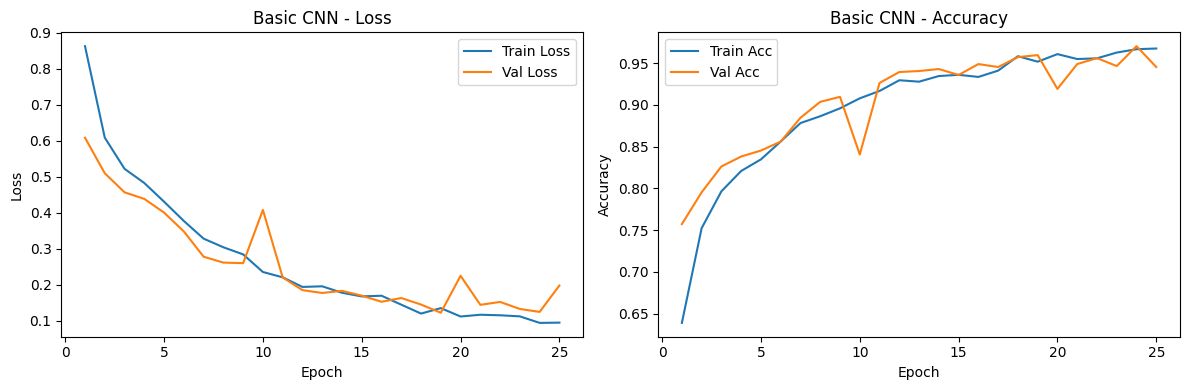

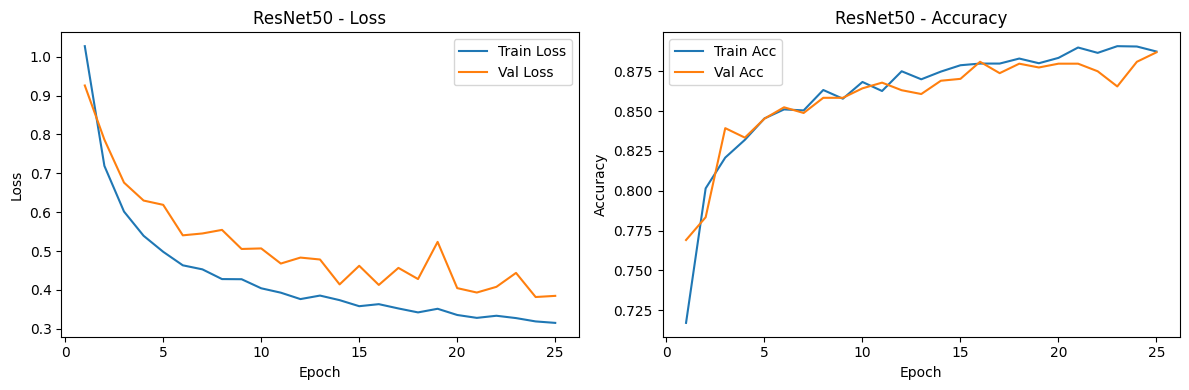

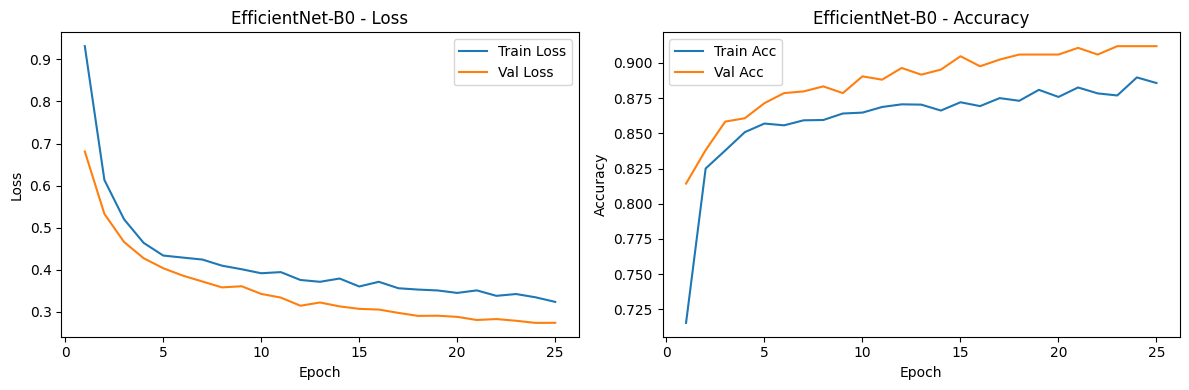

,model,best_val_acc,best_val_loss,best_epoch,final_train_acc,final_val_acc
0,Basic CNN,0.970238,0.124282,24,0.967437,0.945238
1,EfficientNet-B0,0.911905,0.278162,23,0.885714,0.911905
2,ResNet50,0.886905,0.384891,25,0.887395,0.886905


In [16]:
# Plot training and validation curves for each model
for model_name, history in histories.items():
    plot_history(history, model_name)

# Side-by-side comparison summary
comparison_rows = []
for model_name, history in histories.items():
    best_epoch_idx = int(np.argmax(history['val_acc']))
    comparison_rows.append({
        'model': model_name,
        'best_val_acc': history['val_acc'][best_epoch_idx],
        'best_val_loss': history['val_loss'][best_epoch_idx],
        'best_epoch': best_epoch_idx + 1,
        'final_train_acc': history['train_acc'][-1],
        'final_val_acc': history['val_acc'][-1],
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('best_val_acc', ascending=False).reset_index(drop=True)
display(comparison_df)

In [34]:
import json

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

idx_to_class = {v: k for k, v in base_train_ds.class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]


def evaluate_model_on_test(model, loader, class_names):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            preds = torch.argmax(logits, dim=1)

            y_true.extend(labels.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())

    acc = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    report = classification_report(
        y_true, y_pred, target_names=class_names, digits=4, zero_division=0
    )

    return {
        'accuracy': acc,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'confusion_matrix': cm,
        'classification_report': report,
        'y_true': y_true,
        'y_pred': y_pred,
    }


def _last_conv_layer(module):
    for m in reversed(list(module.modules())):
        if isinstance(m, nn.Conv2d):
            return m
    raise ValueError('No Conv2d layer found for Grad-CAM target selection.')


def _set_relu_inplace(module, inplace=False):
    for m in module.modules():
        if isinstance(m, nn.ReLU):
            m.inplace = inplace


def get_gradcam_target_layer(model_name, model):
    if model_name == 'Basic CNN':
        return _last_conv_layer(model.features)
    if model_name == 'ResNet50':
        return model.layer4[-1].conv3
    if model_name == 'EfficientNet-B0':
        return _last_conv_layer(model.features)
    raise ValueError(f'Unknown model name for Grad-CAM: {model_name}')


def compute_gradcam(model, input_tensor, target_layer):
    # Prevent view+inplace autograd conflicts seen in some cloud runtimes.
    _set_relu_inplace(model, inplace=False)

    # Ensure graph exists even when backbone params are frozen.
    input_tensor = input_tensor.clone().detach().requires_grad_(True)

    captured = {}

    def forward_hook(_module, _inp, out):
        captured['acts'] = out

    h = target_layer.register_forward_hook(forward_hook)

    model.eval()
    model.zero_grad(set_to_none=True)

    try:
        logits = model(input_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_class = int(torch.argmax(probs, dim=1).item())
        pred_conf = float(probs[0, pred_class].item())

        score = logits[:, pred_class].sum()
        acts = captured['acts']

        grads = torch.autograd.grad(
            outputs=score,
            inputs=acts,
            retain_graph=False,
            create_graph=False,
            allow_unused=True,
        )[0]

        if grads is None:
            raise RuntimeError('Grad-CAM gradient is None for selected target layer.')

        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1).squeeze(0)
        cam = torch.relu(cam)

        cam_min = cam.min()
        cam_max = cam.max()
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        return cam.detach().cpu().numpy(), pred_class, pred_conf
    finally:
        h.remove()


def cam_focus_score(cam_map):
    flat = cam_map.reshape(-1)
    if np.allclose(flat.sum(), 0):
        return 0.0
    threshold = np.percentile(flat, 90)
    focused_energy = flat[flat >= threshold].sum()
    total_energy = flat.sum() + 1e-8
    return float(focused_energy / total_energy)

## Test Set Evaluation

In [22]:
print(model)

BasicCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=512, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.4, inplace=False)
    (4)


===== Basic CNN | Test Classification Report =====
              precision    recall  f1-score   support

      glioma     0.9280    0.8050    0.8621       400
  meningioma     0.9098    0.9325    0.9210       400
     notumor     0.8906    0.9975    0.9410       400
   pituitary     0.9797    0.9675    0.9736       400

    accuracy                         0.9256      1600
   macro avg     0.9270    0.9256    0.9244      1600
weighted avg     0.9270    0.9256    0.9244      1600



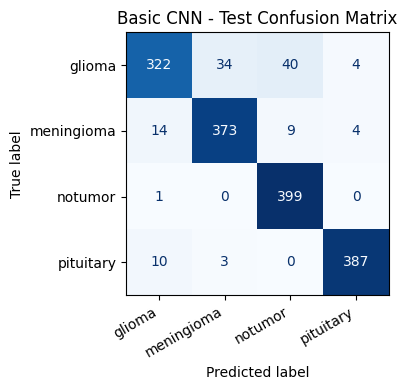


===== ResNet50 | Test Classification Report =====
              precision    recall  f1-score   support

      glioma     0.9361    0.6225    0.7477       400
  meningioma     0.7279    0.7625    0.7448       400
     notumor     0.8045    0.9875    0.8866       400
   pituitary     0.8986    0.9525    0.9248       400

    accuracy                         0.8313      1600
   macro avg     0.8418    0.8313    0.8260      1600
weighted avg     0.8418    0.8313    0.8260      1600



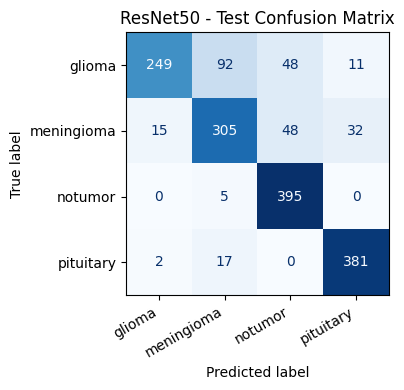


===== EfficientNet-B0 | Test Classification Report =====
              precision    recall  f1-score   support

      glioma     0.9085    0.6950    0.7875       400
  meningioma     0.7551    0.7475    0.7513       400
     notumor     0.7964    0.9875    0.8817       400
   pituitary     0.9104    0.9150    0.9127       400

    accuracy                         0.8363      1600
   macro avg     0.8426    0.8362    0.8333      1600
weighted avg     0.8426    0.8363    0.8333      1600



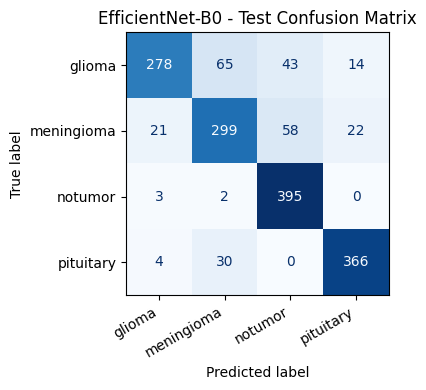

,model,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
0,Basic CNN,0.925625,0.927020,0.925625,0.924431
1,EfficientNet-B0,0.836250,0.842591,0.836250,0.833302
2,ResNet50,0.831250,0.841770,0.831250,0.825990


In [29]:
# Test-set evaluation: accuracy, precision, recall, F1, confusion matrix
eval_results = {}

for model_name, model in trained_models.items():
    result = evaluate_model_on_test(model, test_loader, class_names)
    eval_results[model_name] = result

    print(f'\n===== {model_name} | Test Classification Report =====')
    print(result['classification_report'])

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=result['confusion_matrix'],
        display_labels=class_names,
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(f'{model_name} - Test Confusion Matrix')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

metrics_rows = []
for model_name, result in eval_results.items():
    metrics_rows.append({
        'model': model_name,
        'test_accuracy': result['accuracy'],
        'test_precision_macro': result['precision_macro'],
        'test_recall_macro': result['recall_macro'],
        'test_f1_macro': result['f1_macro'],
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values('test_f1_macro', ascending=False).reset_index(drop=True)
display(metrics_df)

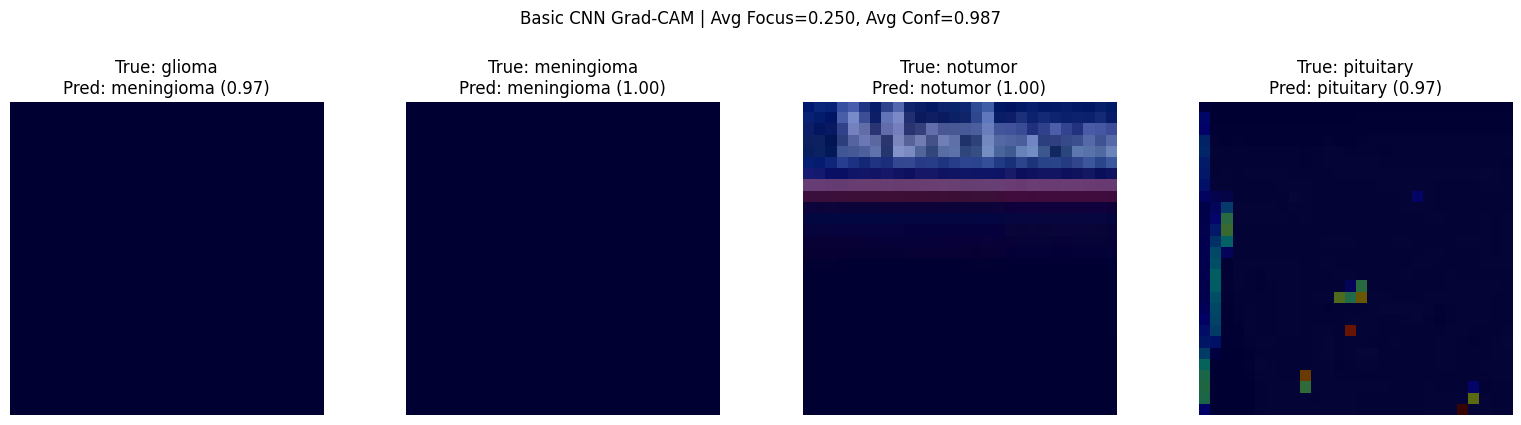

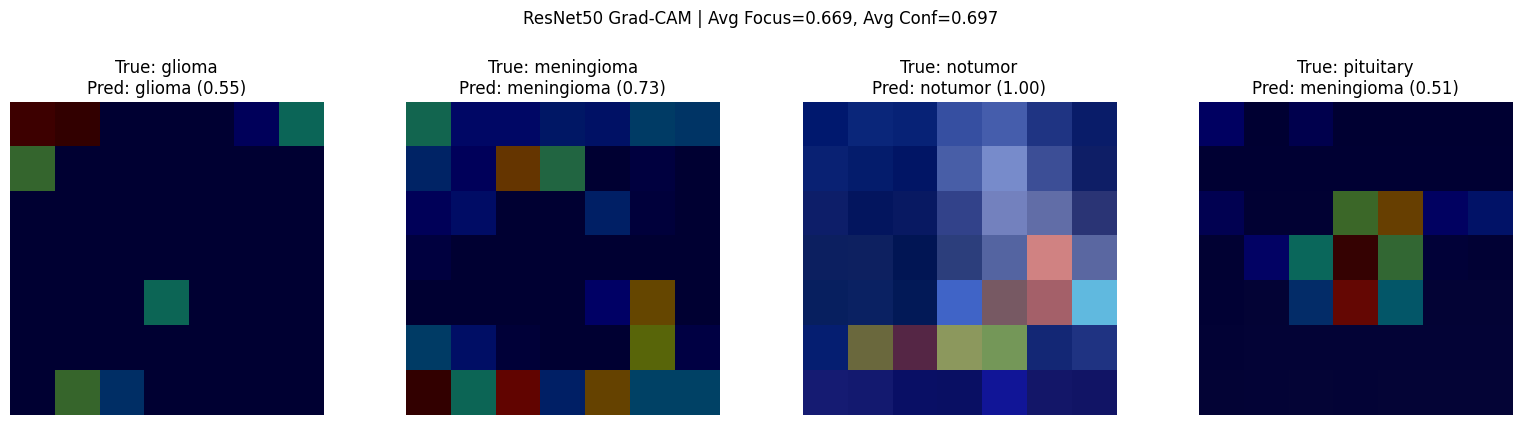

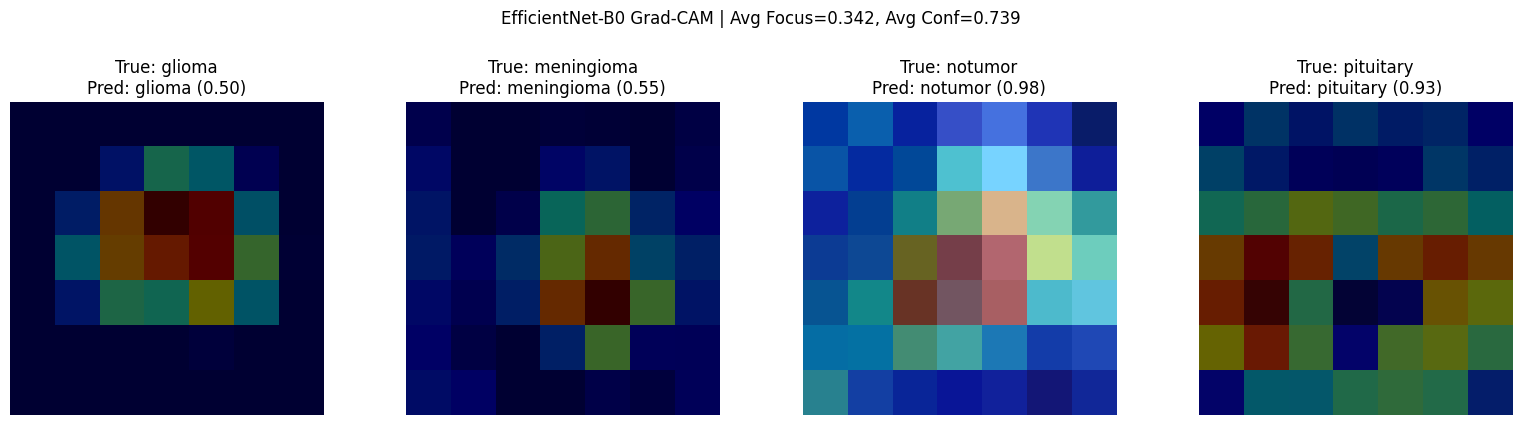

,model,gradcam_focus_score,gradcam_avg_confidence
0,ResNet50,0.668530,0.697373
1,EfficientNet-B0,0.342184,0.738898
2,Basic CNN,0.250000,0.986915


In [35]:
# Grad-CAM visualizations and Grad-CAM quality scoring
sample_indices = []
for class_idx in range(len(class_names)):
    idx_candidates = [i for i, (_p, y) in enumerate(test_ds.samples) if y == class_idx]
    if idx_candidates:
        sample_indices.append(idx_candidates[0])

if not sample_indices:
    raise RuntimeError('No samples found in test dataset for Grad-CAM.')

gradcam_quality = {}

for model_name, model in trained_models.items():
    target_layer = get_gradcam_target_layer(model_name, model)

    focus_scores = []
    conf_scores = []

    fig, axes = plt.subplots(1, len(sample_indices), figsize=(4 * len(sample_indices), 4))
    if len(sample_indices) == 1:
        axes = [axes]

    for col, sample_idx in enumerate(sample_indices):
        img_path, true_label = test_ds.samples[sample_idx]
        pil_img = Image.open(img_path).convert('RGB')

        # Create input tensor using evaluation transform
        input_tensor = eval_transform(pil_img).unsqueeze(0).to(device)
        cam_map, pred_class, pred_conf = compute_gradcam(model, input_tensor, target_layer)

        focus_scores.append(cam_focus_score(cam_map))
        conf_scores.append(pred_conf)

        resized_img = np.array(pil_img.resize((IMG_SIZE, IMG_SIZE)))

        axes[col].imshow(resized_img)
        axes[col].imshow(cam_map, cmap='jet', alpha=0.40)
        axes[col].axis('off')
        axes[col].set_title(
            f'True: {class_names[true_label]}\nPred: {class_names[pred_class]} ({pred_conf:.2f})'
        )

    avg_focus = float(np.mean(focus_scores))
    avg_conf = float(np.mean(conf_scores))
    gradcam_quality[model_name] = {
        'avg_focus': avg_focus,
        'avg_confidence': avg_conf,
    }

    plt.suptitle(
        f'{model_name} Grad-CAM | Avg Focus={avg_focus:.3f}, Avg Conf={avg_conf:.3f}',
        y=1.05,
    )
    plt.tight_layout()
    plt.show()

gradcam_df = pd.DataFrame(
    [
        {
            'model': model_name,
            'gradcam_focus_score': vals['avg_focus'],
            'gradcam_avg_confidence': vals['avg_confidence'],
        }
        for model_name, vals in gradcam_quality.items()
    ]
).sort_values('gradcam_focus_score', ascending=False).reset_index(drop=True)

display(gradcam_df)

In [36]:
# Combine test metrics + Grad-CAM quality, select best model, and save artifacts
selection_df = metrics_df.merge(gradcam_df, on='model', how='left')

# Weighted score: prioritize predictive performance, then visual focus quality
selection_df['final_score'] = (
    0.80 * selection_df['test_f1_macro'] +
    0.20 * selection_df['gradcam_focus_score']
)

selection_df = selection_df.sort_values('final_score', ascending=False).reset_index(drop=True)
display(selection_df)

best_model_name = selection_df.loc[0, 'model']
best_model = trained_models[best_model_name]

print(f'Selected best model: {best_model_name}')

artifacts_dir = PROJECT_ROOT / 'artifacts'
artifacts_dir.mkdir(parents=True, exist_ok=True)

model_save_path = artifacts_dir / 'best_brain_tumor_model.pth'
class_map_path = artifacts_dir / 'class_mapping.json'
metrics_path = artifacts_dir / 'model_comparison_metrics.csv'

checkpoint = {
    'model_name': best_model_name,
    'state_dict': best_model.state_dict(),
    'class_to_idx': base_train_ds.class_to_idx,
    'idx_to_class': idx_to_class,
    'img_size': IMG_SIZE,
}

torch.save(checkpoint, model_save_path)

with open(class_map_path, 'w', encoding='utf-8') as f:
    json.dump({
        'class_to_idx': base_train_ds.class_to_idx,
        'idx_to_class': idx_to_class,
    }, f, indent=2)

selection_df.to_csv(metrics_path, index=False)

print(f'Model saved to: {model_save_path}')
print(f'Class mapping saved to: {class_map_path}')
print(f'Metrics table saved to: {metrics_path}')

,model,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,gradcam_focus_score,gradcam_avg_confidence,final_score
0,ResNet50,0.831250,0.841770,0.831250,0.825990,0.668530,0.697373,0.794498
1,Basic CNN,0.925625,0.927020,0.925625,0.924431,0.250000,0.986915,0.789545
2,EfficientNet-B0,0.836250,0.842591,0.836250,0.833302,0.342184,0.738898,0.735078


Selected best model: ResNet50
Model saved to: /teamspace/studios/this_studio/artifacts/best_brain_tumor_model.pth
Class mapping saved to: /teamspace/studios/this_studio/artifacts/class_mapping.json
Metrics table saved to: /teamspace/studios/this_studio/artifacts/model_comparison_metrics.csv
